In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
from src.ingestion import DataIngestor

/usr/local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
START_DATE = "2024-01-01"
END_DATE   = "2026-05-01"

ingestor = DataIngestor(start_date=START_DATE, end_date=END_DATE, frequency="W")

In [3]:
df_market = ingestor.fetch_market_data(ticker="BTC-USD")
df_market.head()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Volume
timestamp,,,,,
2024-01-07,42280.234375,45899.707031,40813.535156,43943.097656,202311773985
2024-01-14,43948.707031,48969.371094,41724.613281,41796.269531,259971819745
2024-01-21,41715.066406,43566.273438,40297.457031,41545.785156,139135824835
2024-01-28,41553.652344,42797.175781,38521.894531,42035.593750,155314602893
2024-02-04,42030.914062,43838.945312,41818.332031,42583.582031,135184187433


In [4]:
df_mining = ingestor.fetch_mining_metrics()
df_mining.head()

,hash_rate,difficulty
timestamp,,
2024-01-07,5.243887e+08,7.200615e+13
2024-01-14,5.658138e+08,7.319763e+13
2024-01-21,4.649155e+08,7.177058e+13
2024-01-28,6.329200e+08,7.034352e+13
2024-02-04,6.108088e+08,7.134507e+13


In [5]:
df_social = ingestor.fetch_arctic_shift_feed(
    subreddits=["Bitcoin", "CryptoCurrency", "BitcoinMarkets"],
    min_score=5,
)

   Scarico r/Bitcoin...
   r/Bitcoin: 24400 commenti totali...
   Scarico r/CryptoCurrency...
   r/CryptoCurrency: 5700 commenti finora...
   [warn] Errore r/CryptoCurrency [2024-07-15T00:00:00 → 2024-07-21T23:02:35]: 422 Client Error: Unprocessable Entity for url: https://arctic-shift.photon-reddit.com/api/comments/search?subreddit=CryptoCurrency&after=2024-07-15T00:00:00&before=2024-07-21T23:02:35&limit=100&sort=desc&fields=body,score,created_utc
   r/CryptoCurrency: 24300 commenti totali...
   Scarico r/BitcoinMarkets...
   r/BitcoinMarkets: 24400 commenti totali...
   Totale commenti: 14,182
   Periodo: 2024-01-07 → 2026-04-30


In [6]:
import requests
resp = requests.get(
    "https://arctic-shift.photon-reddit.com/api/comments/search",
    params={
        "subreddit": "Bitcoin",
        "after":     "2024-01-01T00:00:00",
        "before":    "2024-01-08T00:00:00",
        "limit":     100,
        "sort":      "desc",
        "fields":    "body,score,created_utc",
    }
)
print(resp.status_code)
print(resp.text[:300])

200
{"data":[{"body":"Thank you so much","created_utc":1704671996,"score":2},{"body":"Does it matter? Government can default","created_utc":1704671964,"score":1},{"body":"And then next Friday a headline: *A series of violent memes put on halt BTC's ETF approval pending investigation* :-D","created_utc":


In [7]:
df_social.head()

,timestamp,source,text,user_followers
0,2024-01-07 03:59:42,Reddit_r/BitcoinMarkets,"Historically, the best time to sell is 18 mont...",11
1,2024-01-07 04:04:44,Reddit_r/BitcoinMarkets,Estimates are closer to 5 billion in the first...,7
2,2024-01-07 05:03:43,Reddit_r/BitcoinMarkets,As far as I know bitcoin etf will be approved ...,6
3,2024-01-07 05:11:04,Reddit_r/BitcoinMarkets,It’s a vote. Gary is one of five. He is expect...,9
4,2024-01-07 05:19:15,Reddit_r/BitcoinMarkets,https://twitter.com/ericbalchunas/status/17436...,19


In [8]:
print("📊 Statistiche temporali del dataset:")
print(f"Data MINIMA trovata: {df_social['timestamp'].min()}")
print(f"Data MASSIMA trovata: {df_social['timestamp'].max()}")
print(f"Totale righe nel DataFrame: {len(df_social)}")
print(f"Numero di valori nulli (NaT): {df_social['timestamp'].isna().sum()}")
print("\n🔍 Prime 5 righe del dataset:")
print(df_social[['timestamp', 'source']].head())
print("\n📌 Conteggio per fonte:")
print(df_social['source'].value_counts())

📊 Statistiche temporali del dataset:
Data MINIMA trovata: 2024-01-07 03:59:42
Data MASSIMA trovata: 2026-04-30 23:56:36
Totale righe nel DataFrame: 14182
Numero di valori nulli (NaT): 0

🔍 Prime 5 righe del dataset:
            timestamp                   source
0 2024-01-07 03:59:42  Reddit_r/BitcoinMarkets
1 2024-01-07 04:04:44  Reddit_r/BitcoinMarkets
2 2024-01-07 05:03:43  Reddit_r/BitcoinMarkets
3 2024-01-07 05:11:04  Reddit_r/BitcoinMarkets
4 2024-01-07 05:19:15  Reddit_r/BitcoinMarkets

📌 Conteggio per fonte:
source
Reddit_r/BitcoinMarkets    7322
Reddit_r/Bitcoin           3594
Reddit_r/CryptoCurrency    3266
Name: count, dtype: int64


In [9]:
ELECTRICITY_PRICE_KWH = 0.05
df_energy = ingestor.fetch_energy_cost(electricity_price_kwh=ELECTRICITY_PRICE_KWH)

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})
print('✅ Matplotlib configurato.')

✅ Matplotlib configurato.


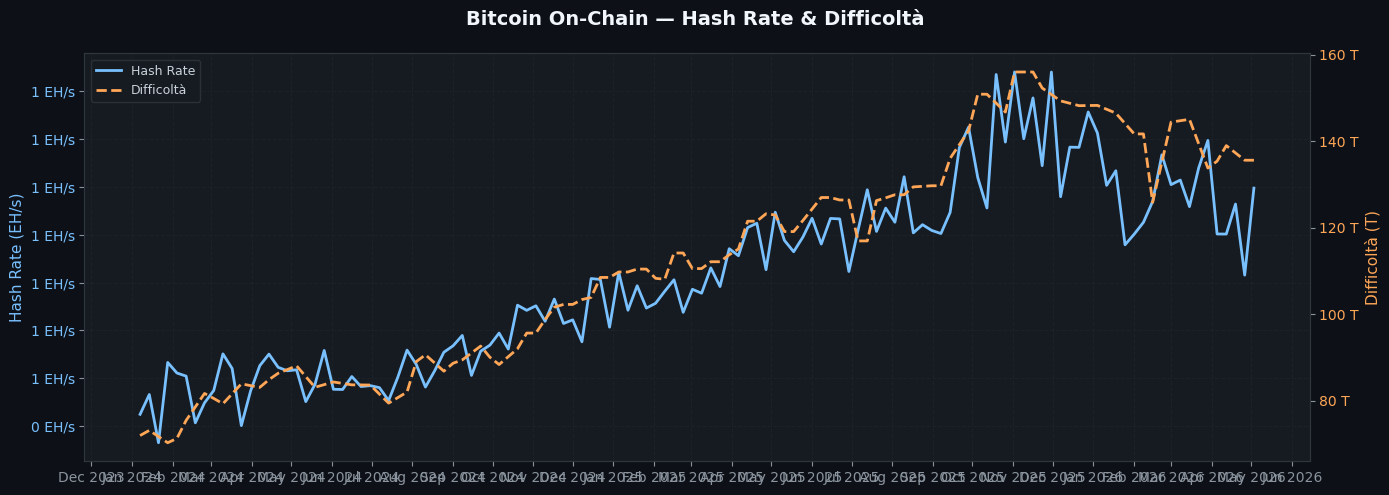

✅ Grafico mining salvato.


In [11]:
fig, ax1 = plt.subplots(figsize=(14, 5))
fig.suptitle('Bitcoin On-Chain — Hash Rate & Difficoltà', fontsize=14, fontweight='bold', color='#f0f6fc')

color_hr = '#79c0ff'
ax1.set_ylabel('Hash Rate (EH/s)', fontsize=11, color=color_hr)
ax1.plot(df_mining.index, df_mining['hash_rate'] / 1e9,
         color=color_hr, linewidth=2, label='Hash Rate')
ax1.tick_params(axis='y', labelcolor=color_hr)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f} EH/s'))

ax2 = ax1.twinx()
color_diff = '#ffa657'
ax2.set_ylabel('Difficoltà (T)', fontsize=11, color=color_diff)
ax2.plot(df_mining.index, df_mining['difficulty'] / 1e12,
         color=color_diff, linewidth=2, linestyle='--', label='Difficoltà')
ax2.tick_params(axis='y', labelcolor=color_diff)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f} T'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.grid(True)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('./data/chart_mining.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafico mining salvato.')

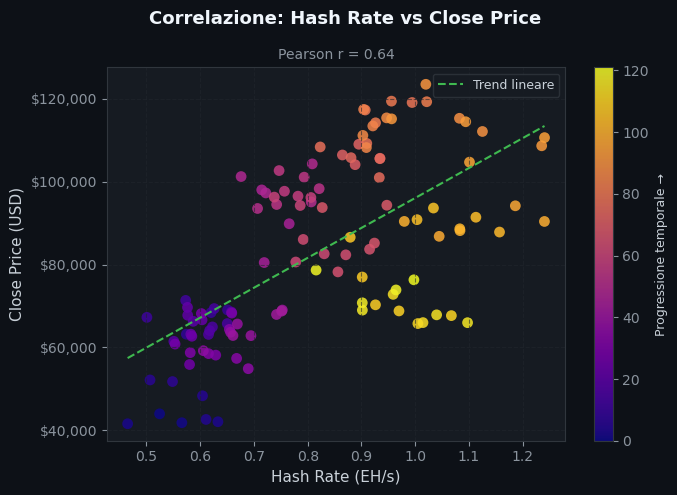

📐 Correlazione Pearson (hash_rate vs Close): 0.644


In [12]:
df_combined = df_market[['Close']].join(df_mining[['hash_rate']], how='inner')

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Correlazione: Hash Rate vs Close Price', fontsize=13, fontweight='bold', color='#f0f6fc')

sc = ax.scatter(df_combined['hash_rate'] / 1e9, df_combined['Close'],
                c=range(len(df_combined)), cmap='plasma',
                s=60, alpha=0.85, edgecolors='none')

z = np.polyfit(df_combined['hash_rate'] / 1e9, df_combined['Close'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_combined['hash_rate'].min() / 1e9,
                     df_combined['hash_rate'].max() / 1e9, 100)
ax.plot(x_line, p(x_line), color='#3fb950', linewidth=1.5,
        linestyle='--', label='Trend lineare')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Progressione temporale →', fontsize=9)

corr = df_combined['hash_rate'].corr(df_combined['Close'])
ax.set_xlabel('Hash Rate (EH/s)', fontsize=11)
ax.set_ylabel('Close Price (USD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9)
ax.set_title(f'Pearson r = {corr:.2f}', fontsize=10, color='#8b949e')
ax.grid(True)
plt.tight_layout()
plt.savefig('./data/chart_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📐 Correlazione Pearson (hash_rate vs Close): {corr:.3f}')

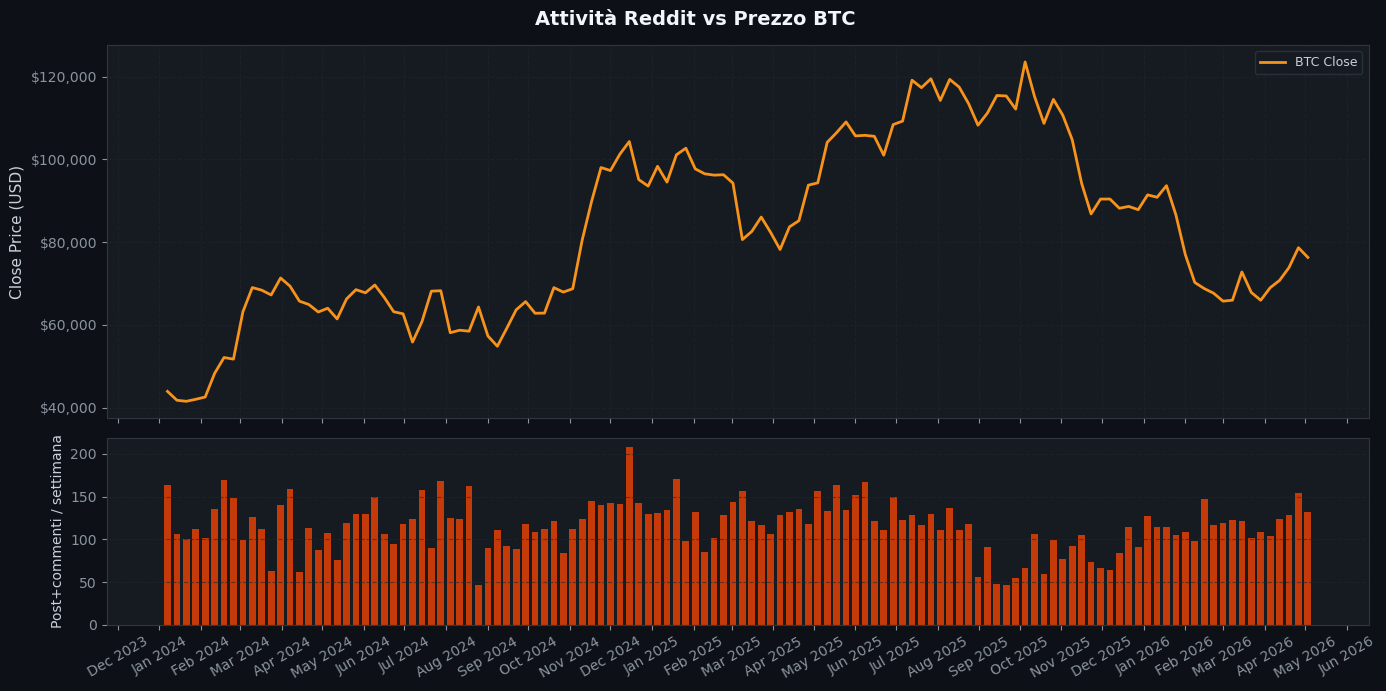

In [13]:
df_social_weekly = (
    df_social.assign(timestamp=pd.to_datetime(df_social['timestamp']))
    .set_index('timestamp')
    .resample('W')
    .size()
    .rename('post_count')
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('Attività Reddit vs Prezzo BTC', fontsize=14, fontweight='bold', color='#f0f6fc')

ax1.plot(df_market.index, df_market['Close'],
         color='#f7931a', linewidth=2, label='BTC Close')
ax1.set_ylabel('Close Price (USD)', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(True)

ax2.bar(df_social_weekly.index, df_social_weekly,
        width=5, color='#ff4500', alpha=0.75, edgecolor='none')
ax2.set_ylabel('Post+commenti / settimana', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.grid(True, axis='y')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('./data/chart_social_volume.png', dpi=150, bbox_inches='tight')
plt.show()

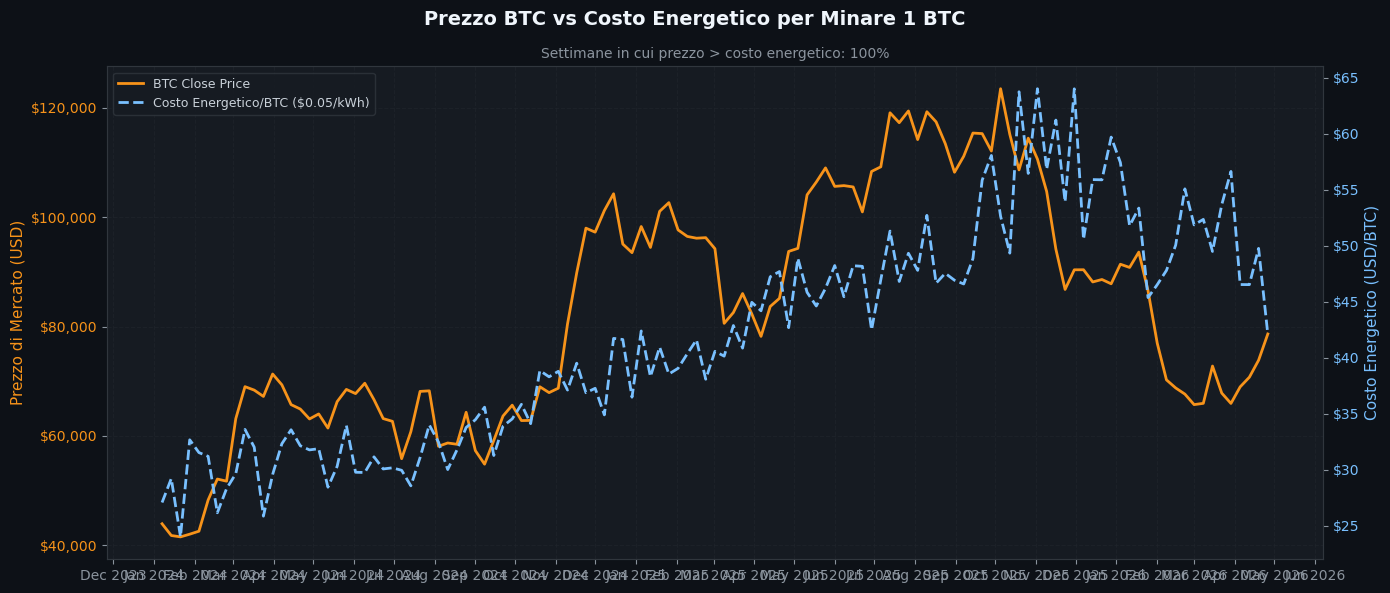

In [14]:
df_combo = df_market[['Close']].join(df_energy[['cost_per_btc_usd']], how='inner')

fig, ax1 = plt.subplots(figsize=(14, 6))
fig.suptitle('Prezzo BTC vs Costo Energetico per Minare 1 BTC', fontsize=14, fontweight='bold', color='#f0f6fc')

ax1.plot(df_combo.index, df_combo['Close'], color='#f7931a', linewidth=2, label='BTC Close Price')
ax1.set_ylabel('Prezzo di Mercato (USD)', fontsize=11, color='#f7931a')
ax1.tick_params(axis='y', labelcolor='#f7931a')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(df_combo.index, df_combo['cost_per_btc_usd'], color='#79c0ff', linewidth=2,
         linestyle='--', label=f'Costo Energetico/BTC (${ELECTRICITY_PRICE_KWH}/kWh)')
ax2.set_ylabel('Costo Energetico (USD/BTC)', fontsize=11, color='#79c0ff')
ax2.tick_params(axis='y', labelcolor='#79c0ff')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

profitable_pct = (df_combo['Close'].values > df_combo['cost_per_btc_usd'].values).mean() * 100
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.grid(True)
plt.xticks(rotation=30)
ax1.set_title(f'Settimane in cui prezzo > costo energetico: {profitable_pct:.0f}%',
              fontsize=10, color='#8b949e')
plt.tight_layout()
plt.savefig('./data/chart_energy_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## Sentiment Analysis (Gemini)

In [15]:
# Verifica che SentimentEngine sia importabile correttamente
from src.sentiment_engine import SentimentEngine
print("✅ SentimentEngine importato correttamente.")

✅ SentimentEngine importato correttamente.


In [16]:
from dotenv import load_dotenv
from src.sentiment_engine import SentimentEngine

load_dotenv()

engine = SentimentEngine(api_key=os.getenv("GEMINI_API_KEY"))

df_sentiment = engine.analyze(df_social)
df_sentiment.head()

/home/shinomi/Projects/snap/src/sentiment_engine.py:21: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  text = BeautifulSoup(text, "html.parser").get_text()


   12,917 tweet → 130 batch da 100
   Batch 130/130 completato
   Salvato in ./data/bitcoin_sentiment.csv


,sentiment_score_mean,sentiment_score_weighted,positive_pct,negative_pct,tweet_count
timestamp,,,,,
2024-01-07,-0.031126,-0.066457,37.748344,41.059603,151.0
2024-01-14,-0.073000,-0.050540,28.000000,50.000000,100.0
2024-01-21,0.048352,0.133866,31.868132,27.472527,91.0
2024-01-28,0.068000,0.048793,50.000000,33.000000,100.0
2024-02-04,0.024490,0.061057,41.836735,27.551020,98.0


In [17]:
df_sentiment = pd.read_csv('./data/bitcoin_sentiment.csv', index_col='timestamp', parse_dates=True)

In [18]:
full_idx = pd.date_range(
    start=df_sentiment.index.min(),
    end=df_sentiment.index.max(),
    freq='W',
)
df_sentiment = df_sentiment.reindex(full_idx)
df_sentiment['has_data']    = (df_sentiment['tweet_count'] > 0).astype(int)
df_sentiment['tweet_count'] = df_sentiment['tweet_count'].fillna(0)

cols_interp = ['sentiment_score_mean', 'sentiment_score_weighted', 'positive_pct', 'negative_pct']
df_sentiment[cols_interp] = df_sentiment[cols_interp].ffill(limit=4)

print(f'Settimane totali:      {len(df_sentiment)}')
print(f'Settimane con dati:    {df_sentiment["has_data"].sum()}')
print(f'Settimane interpolate: {(df_sentiment["has_data"] == 0).sum()}')
df_sentiment.head(10)

Settimane totali:      122
Settimane con dati:    122
Settimane interpolate: 0


,sentiment_score_mean,sentiment_score_weighted,positive_pct,negative_pct,tweet_count,has_data
2024-01-07,-0.031126,-0.066457,37.748344,41.059603,151.0,1
2024-01-14,-0.073000,-0.050540,28.000000,50.000000,100.0,1
2024-01-21,0.048352,0.133866,31.868132,27.472527,91.0,1
2024-01-28,0.068000,0.048793,50.000000,33.000000,100.0,1
2024-02-04,0.024490,0.061057,41.836735,27.551020,98.0,1
2024-02-11,0.036000,-0.072989,40.800000,37.600000,125.0,1
2024-02-18,0.088679,0.039532,48.427673,30.817610,159.0,1
2024-02-25,0.085612,0.094355,49.640288,32.374101,139.0,1
2024-03-03,0.176087,0.130440,57.608696,22.826087,92.0,1
2024-03-10,0.007143,0.002411,40.178571,37.500000,112.0,1


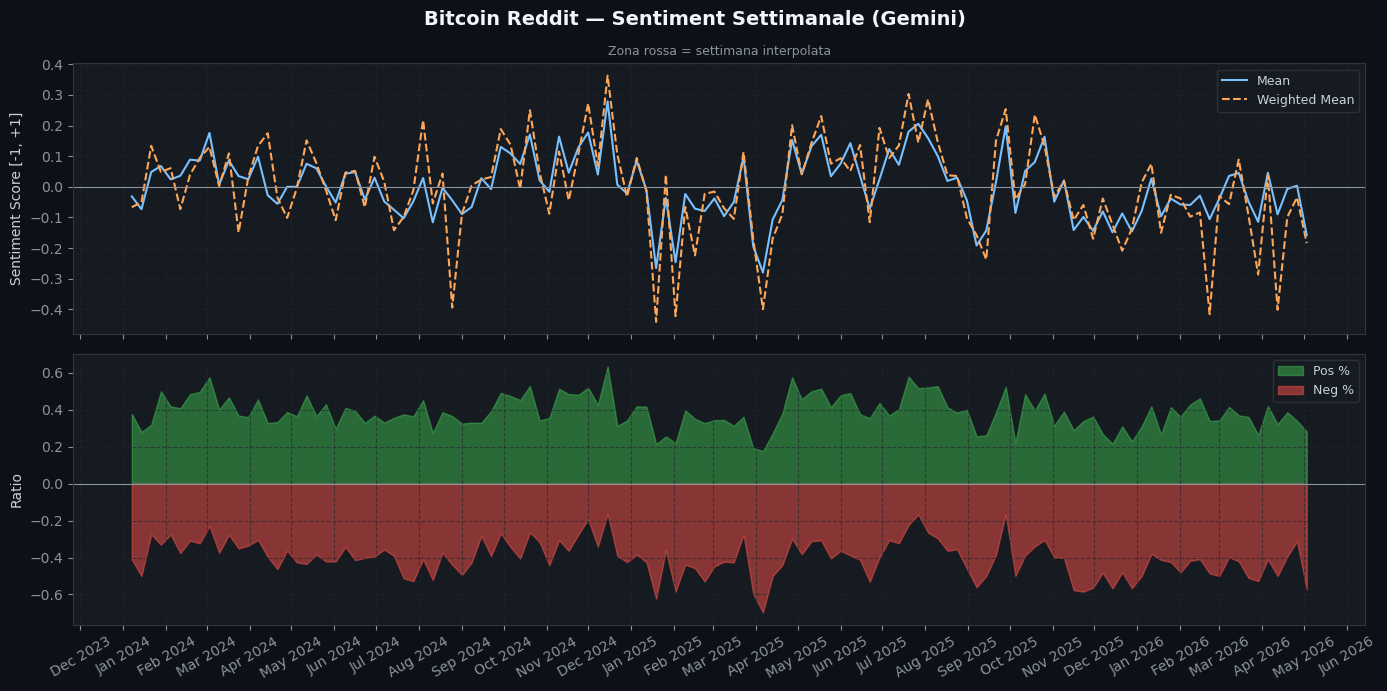

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Bitcoin Reddit — Sentiment Settimanale (Gemini)', fontsize=14, fontweight='bold', color='#f0f6fc')

axes[0].plot(df_sentiment.index, df_sentiment['sentiment_score_mean'],
             color='#79c0ff', linewidth=1.5, label='Mean')
axes[0].plot(df_sentiment.index, df_sentiment['sentiment_score_weighted'],
             color='#ffa657', linewidth=1.5, linestyle='--', label='Weighted Mean')
axes[0].axhline(0, color='#8b949e', linewidth=0.8)
for idx in df_sentiment[df_sentiment['has_data'] == 0].index:
    axes[0].axvspan(idx - pd.Timedelta(days=3), idx + pd.Timedelta(days=3),
                    alpha=0.15, color='#f85149')
axes[0].set_ylabel('Sentiment Score [-1, +1]', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].set_title('Zona rossa = settimana interpolata', fontsize=9, color='#8b949e')
axes[0].grid(True)

axes[1].fill_between(df_sentiment.index, df_sentiment['positive_pct'] / 100,
                     alpha=0.5, color='#3fb950', label='Pos %')
axes[1].fill_between(df_sentiment.index, -df_sentiment['negative_pct'] / 100,
                     alpha=0.5, color='#f85149', label='Neg %')
axes[1].axhline(0, color='#8b949e', linewidth=0.8)
axes[1].set_ylabel('Ratio', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('./data/chart_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Engineering (RSI, MACD, Sharpe)

In [20]:
# Feature tecniche
tech = engine.compute_technical_features(df_market)

print(f'Feature tecniche: {tech.shape[1]} colonne, {tech.shape[0]} settimane')
print(f'NaN warm-up: {tech.isna().any(axis=1).sum()} righe')
tech.head()

Feature tecniche: 8 colonne, 122 settimane
NaN warm-up: 14 righe


,log_return,volatility_w,rsi_14,macd,macd_signal,macd_hist,sharpe_4w,volume_norm
timestamp,,,,,,,,
2024-01-07,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
2024-01-14,-0.050088,NaN,NaN,-171.256944,-34.251389,-137.005556,NaN,NaN
2024-01-21,-0.006011,NaN,NaN,-323.462627,-92.093636,-231.368990,NaN,NaN
2024-01-28,0.011721,NaN,NaN,-399.952859,-153.665481,-246.287378,NaN,0.820973
2024-02-04,0.012952,0.028904,NaN,-411.609071,-205.254199,-206.354872,-1.872499,0.784124


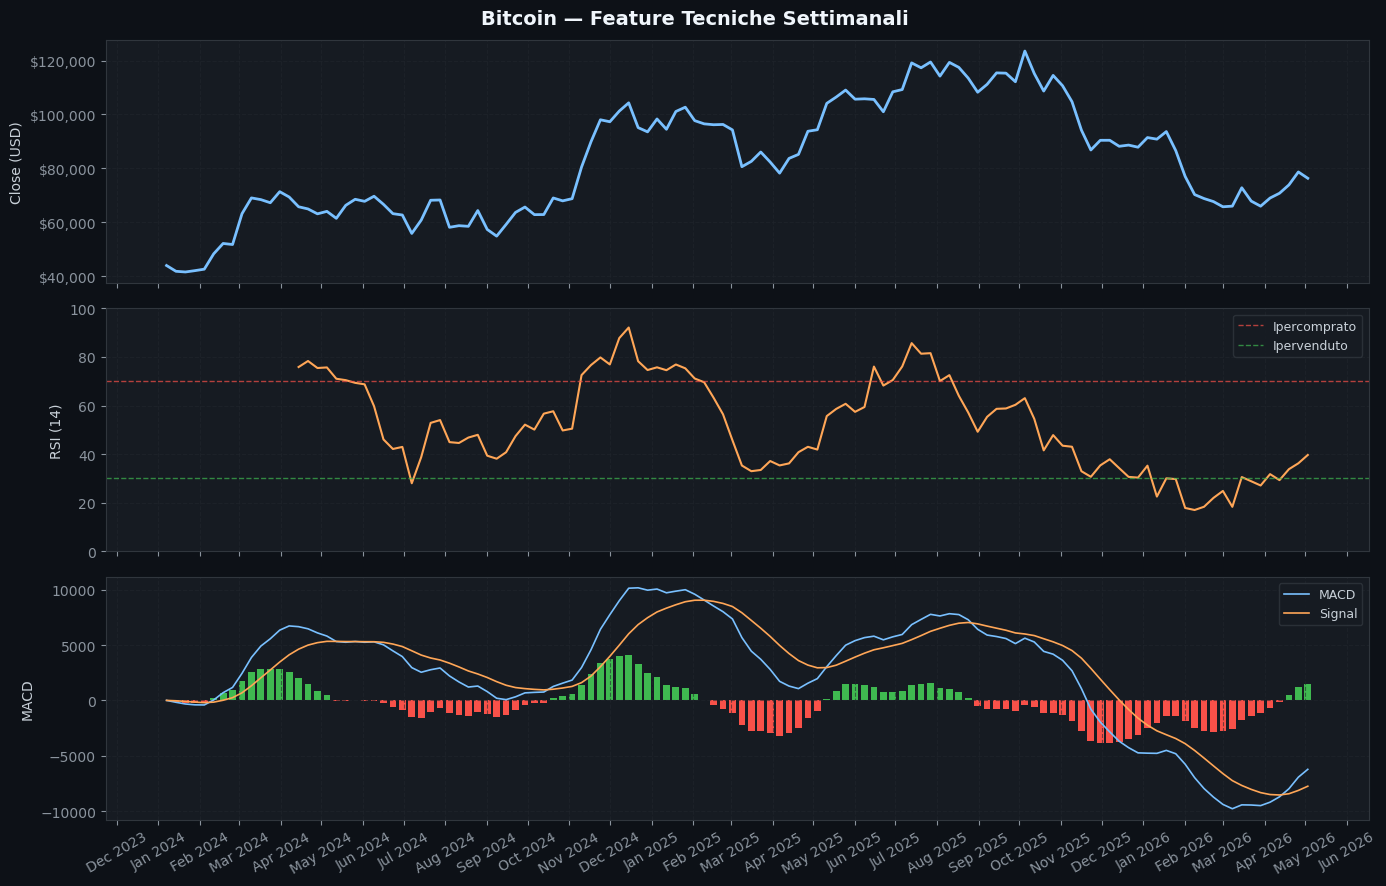

✅ Grafico feature tecniche salvato.


In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Bitcoin — Feature Tecniche Settimanali', fontsize=14, fontweight='bold', color='#f0f6fc')

axes[0].plot(df_market.index, df_market['Close'], color='#79c0ff', linewidth=2)
axes[0].set_ylabel('Close (USD)', fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(True)

axes[1].plot(tech.index, tech['rsi_14'], color='#ffa657', linewidth=1.5)
axes[1].axhline(70, color='#f85149', linestyle='--', linewidth=1, alpha=0.7, label='Ipercomprato')
axes[1].axhline(30, color='#3fb950', linestyle='--', linewidth=1, alpha=0.7, label='Ipervenduto')
axes[1].set_ylabel('RSI (14)', fontsize=10)
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=9)
axes[1].grid(True)

colors = ['#3fb950' if v >= 0 else '#f85149' for v in tech['macd_hist'].fillna(0)]
axes[2].bar(tech.index, tech['macd_hist'].fillna(0), color=colors, width=5)
axes[2].plot(tech.index, tech['macd'],        color='#79c0ff', linewidth=1.2, label='MACD')
axes[2].plot(tech.index, tech['macd_signal'], color='#ffa657', linewidth=1.2, label='Signal')
axes[2].set_ylabel('MACD', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('./data/chart_tech_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafico feature tecniche salvato.')

In [22]:
# Feature energia
energy_feats = engine.compute_energy_features(df_energy)
energy_feats.head()

,cost_per_btc,cost_per_btc_delta,hash_rate_norm
timestamp,,,
2024-01-07,27.065223,NaN,NaN
2024-01-14,29.203294,0.078997,NaN
2024-01-21,23.995637,-0.178324,NaN
2024-01-28,32.666836,0.361366,1.157055
2024-02-04,31.525614,-0.034935,1.074205


## Feature Matrix + XGBoost

In [23]:
# Assembla feature matrix manualmente (sentiment già calcolato, evita di richiamarlo)
feature_matrix = tech.join(df_sentiment, how='left').join(energy_feats, how='left')
feature_matrix = feature_matrix.ffill(limit=1)
feature_matrix = feature_matrix.iloc[:-1]  # ultima settimana non ancora chiusa

print(f'Feature matrix: {feature_matrix.shape[0]} settimane × {feature_matrix.shape[1]} feature')
print(f'Periodo: {feature_matrix.index[0].date()} → {feature_matrix.index[-1].date()}')
print()
for col in feature_matrix.columns:
    print(f'  {col:<35} NaN: {feature_matrix[col].isna().sum()}')

Feature matrix: 121 settimane × 17 feature
Periodo: 2024-01-07 → 2026-04-26

  log_return                          NaN: 1
  volatility_w                        NaN: 4
  rsi_14                              NaN: 14
  macd                                NaN: 0
  macd_signal                         NaN: 0
  macd_hist                           NaN: 0
  sharpe_4w                           NaN: 4
  volume_norm                         NaN: 3
  sentiment_score_mean                NaN: 0
  sentiment_score_weighted            NaN: 0
  positive_pct                        NaN: 0
  negative_pct                        NaN: 0
  tweet_count                         NaN: 0
  has_data                            NaN: 0
  cost_per_btc                        NaN: 0
  cost_per_btc_delta                  NaN: 1
  hash_rate_norm                      NaN: 3


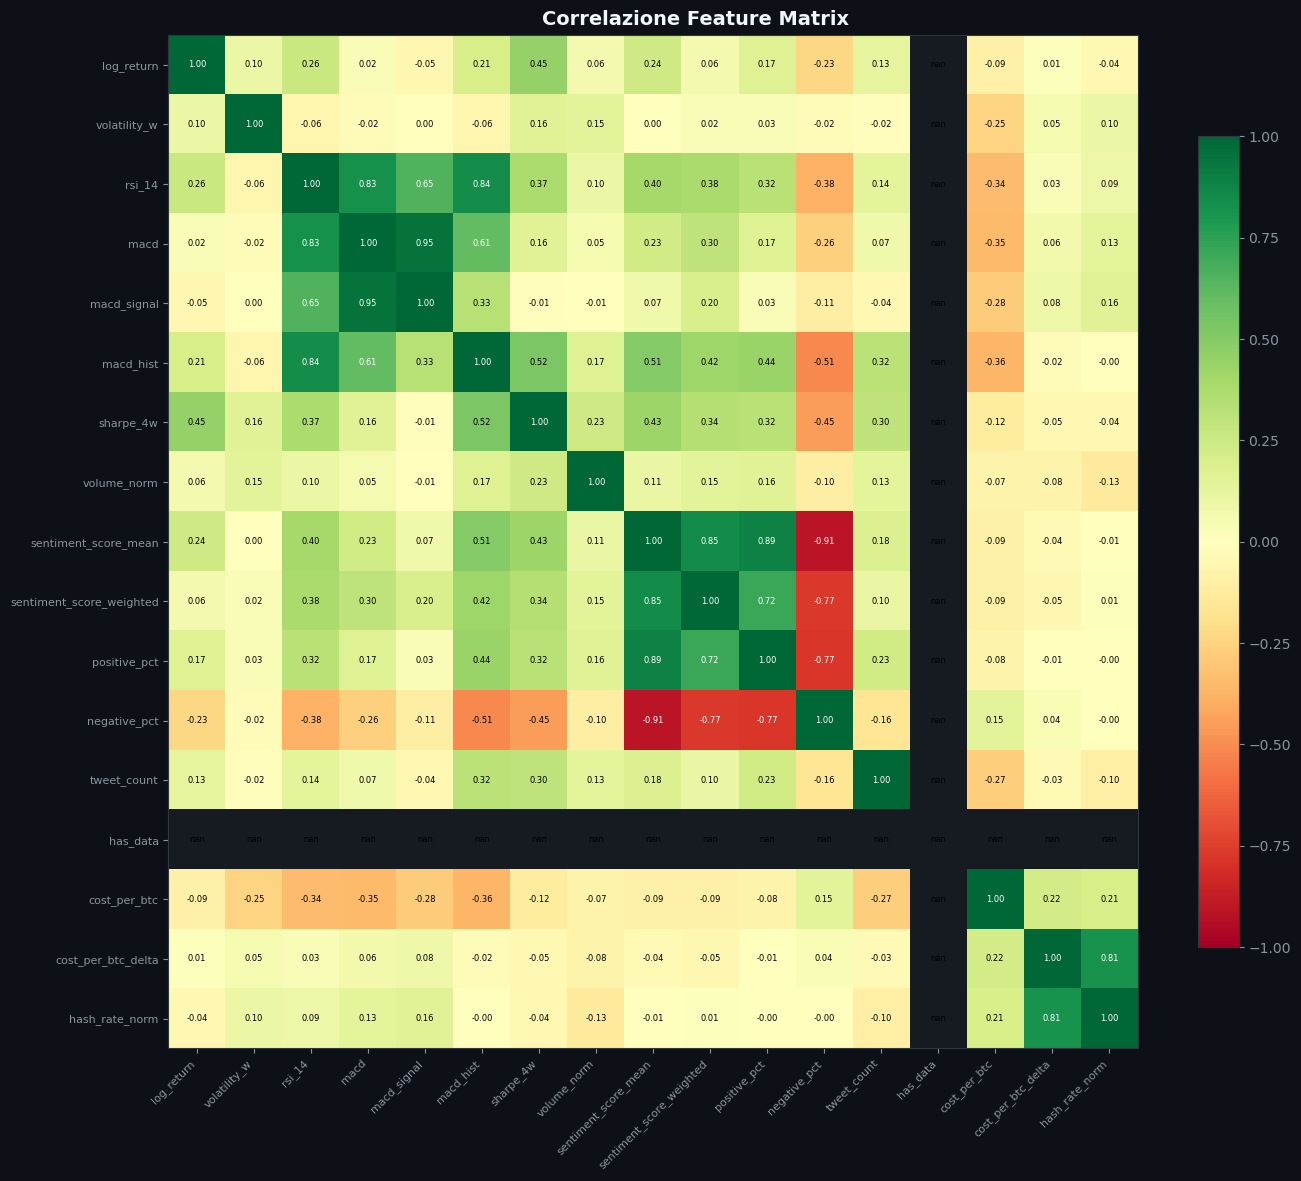

In [24]:
import matplotlib

corr = feature_matrix.dropna().corr()
fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('Correlazione Feature Matrix', fontsize=14, fontweight='bold', color='#f0f6fc')
cmap = matplotlib.colormaps.get_cmap('RdYlGn')
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6,
                color='white' if abs(val) > 0.6 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('./data/chart_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Target: prezzo su o giù la settimana successiva
close = df_market['Close']
target = []
for t in feature_matrix.index:
    t_idx = close.index.get_loc(t)
    up = int(close.iloc[t_idx + 1] > close.iloc[t_idx]) if t_idx + 1 < len(close) else np.nan
    target.append(up)

y = pd.Series(target, index=feature_matrix.index, name='target_up')
print('Target distribution:')
print(y.value_counts())
print(f'\nUP ratio: {y.mean():.1%}')

Target distribution:
target_up
1    61
0    60
Name: count, dtype: int64

UP ratio: 50.4%


In [26]:
X = feature_matrix.dropna()
y_clean = y.loc[X.index].dropna()
X_clean = X.loc[y_clean.index]

split = int(len(X_clean) * 0.7)
X_train = X_clean.iloc[:split]
y_train = y_clean.iloc[:split]
X_test  = X_clean.iloc[split:]
y_test  = y_clean.iloc[split:]

print(f"Train: {len(X_train)} settimane | Test: {len(X_test)} settimane")

Train: 74 settimane | Test: 33 settimane


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import xgboost as xgb

param_grid = {
    'n_estimators':     [50, 100],
    'max_depth':        [2, 3],
    'learning_rate':    [0.01, 0.05],
    'subsample':        [0.6, 0.7],
    'colsample_bytree': [0.5, 0.6],
    'min_child_weight': [3, 5, 10],
    'gamma':            [0.1, 0.3, 1],
    'reg_alpha':        [0.1, 0.5, 1],
    'reg_lambda':       [1, 2, 5],
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

best_params = search.best_params_
print(f'Migliori parametri: {best_params}')
print(f'Miglior AUC in CV:  {search.best_score_:.3f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Migliori parametri: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}
Miglior AUC in CV:  0.669


In [28]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

X = feature_matrix.dropna()
y_clean = y.loc[X.index].dropna()
X_clean = X.loc[y_clean.index]

MIN_TRAIN_SIZE = 30  # settimane minime prima di iniziare a predire

predictions = []
probabilities = []
actuals = []
test_dates = []

for i in range(MIN_TRAIN_SIZE, len(X_clean)):
    X_train = X_clean.iloc[:i]
    y_train = y_clean.iloc[:i]
    X_test  = X_clean.iloc[i:i+1]
    y_test  = y_clean.iloc[i:i+1]

    model = xgb.XGBClassifier(**best_params, eval_metric='logloss', random_state=42)
    model.fit(X_train, y_train)

    predictions.append(model.predict(X_test)[0])
    probabilities.append(model.predict_proba(X_test)[0, 1])
    actuals.append(y_test.values[0])
    test_dates.append(X_test.index[0])

predictions   = np.array(predictions)
probabilities = np.array(probabilities)
actuals       = np.array(actuals)

acc = accuracy_score(actuals, predictions)
auc = roc_auc_score(actuals, probabilities)

print(f'📊 Walk-Forward Validation (expanding window, parametri ottimizzati):')
print(f'   Predizioni totali: {len(predictions)}')
print(f'   Accuracy : {acc:.3f}')
print(f'   ROC-AUC  : {auc:.3f}')

📊 Walk-Forward Validation (expanding window, parametri ottimizzati):
   Predizioni totali: 77
   Accuracy : 0.429
   ROC-AUC  : 0.417


In [29]:
print(f"Totale commenti social: {len(df_social)}")
print(f"Periodo social: {df_social['timestamp'].min().date()} → {df_social['timestamp'].max().date()}")
print(f"Settimane sentiment con dati reali: {df_sentiment['has_data'].sum()}")
print(f"Settimane sentiment interpolate: {(df_sentiment['has_data'] == 0).sum()}")

Totale commenti social: 14182
Periodo social: 2024-01-07 → 2026-04-30
Settimane sentiment con dati reali: 122
Settimane sentiment interpolate: 0


In [30]:
print(f"MIN_TRAIN_SIZE: {MIN_TRAIN_SIZE}")
print(f"len(X_clean): {len(X_clean)}")
print(f"Predizioni attese: {len(X_clean) - MIN_TRAIN_SIZE}")

MIN_TRAIN_SIZE: 30
len(X_clean): 107
Predizioni attese: 77


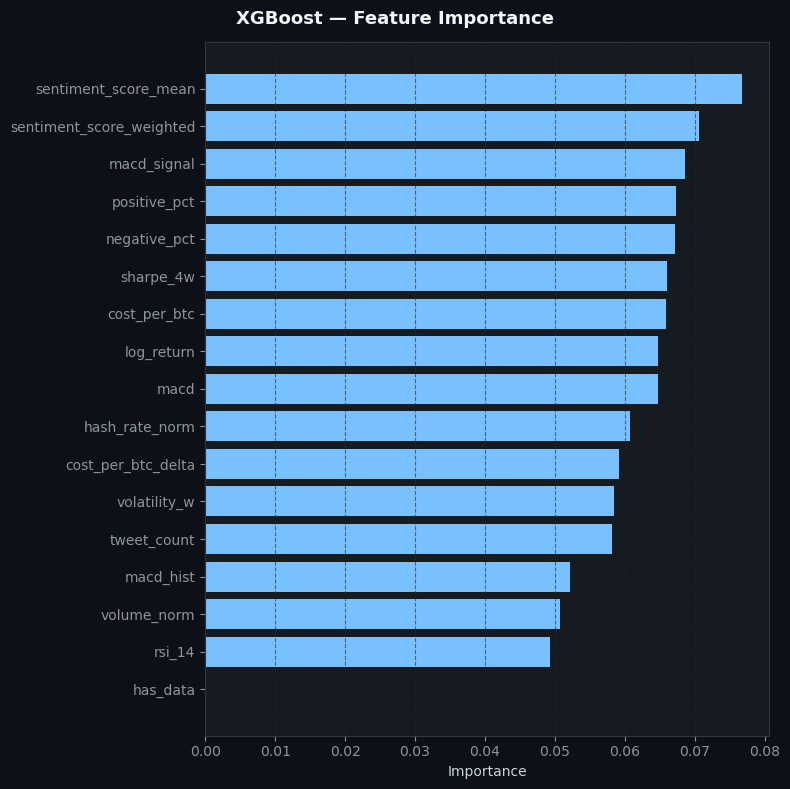

In [31]:
importance = pd.Series(model.feature_importances_, index=X_clean.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
fig.suptitle('XGBoost — Feature Importance', fontsize=13, fontweight='bold', color='#f0f6fc')
ax.barh(importance.index, importance.values, color='#79c0ff')
ax.set_xlabel('Importance', fontsize=10)
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('./data/chart_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ── BASELINE 1: Buy & Hold ──────────────────────────────────────────────
# Strategia: prevedi sempre "su" (assume che il prezzo salirà sempre)
buy_hold_predictions = np.ones(len(actuals), dtype=int)
buy_hold_acc = accuracy_score(actuals, buy_hold_predictions)

# ── BASELINE 2: MACD Crossover ──────────────────────────────────────────
# Strategia classica: segnale "su" quando macd > macd_signal (trend rialzista)
macd_signal_col = X_clean['macd'] > X_clean['macd_signal']
macd_predictions = macd_signal_col.astype(int).values[MIN_TRAIN_SIZE:]
macd_acc = accuracy_score(actuals, macd_predictions)

# AUC per MACD: usiamo la differenza macd - macd_signal normalizzata come proxy di probabilità
macd_diff = (X_clean['macd'] - X_clean['macd_signal']).values[MIN_TRAIN_SIZE:]
macd_prob = (macd_diff - macd_diff.min()) / (macd_diff.max() - macd_diff.min() + 1e-9)
macd_auc = roc_auc_score(actuals, macd_prob)

# ── BASELINE 3: Random ──────────────────────────────────────────────────
np.random.seed(1221)
random_predictions = np.random.randint(0, 2, size=len(actuals))
random_prob = np.random.uniform(0, 1, size=len(actuals))
random_acc = accuracy_score(actuals, random_predictions)
random_auc = roc_auc_score(actuals, random_prob)

# ── CONFRONTO FINALE ─────────────────────────────────────────────────────
print('📊 Confronto Walk-Forward Validation (stesso periodo di test)\n')
print(f'{"Strategia":<20} {"Accuracy":<12} {"ROC-AUC":<10}')
print('-' * 42)
print(f'{"XGBoost (nostro)":<20} {acc:<12.3f} {auc:<10.3f}')
print(f'{"Buy & Hold":<20} {buy_hold_acc:<12.3f} {"N/A":<10}')
print(f'{"MACD Crossover":<20} {macd_acc:<12.3f} {macd_auc:<10.3f}')
print(f'{"Random":<20} {random_acc:<12.3f} {random_auc:<10.3f}')

📊 Confronto Walk-Forward Validation (stesso periodo di test)

Strategia            Accuracy     ROC-AUC   
------------------------------------------
XGBoost (nostro)     0.429        0.417     
Buy & Hold           0.494        N/A       
MACD Crossover       0.506        0.494     
Random               0.571        0.491     


In [33]:
# ── ROBUSTEZZA: Random baseline su più seed ──────────────────────────────
random_aucs = []
random_accs = []

N_SEEDS = 50
for seed in range(N_SEEDS):
    rng = np.random.RandomState(seed)
    rand_pred = rng.randint(0, 2, size=len(actuals))
    rand_prob = rng.uniform(0, 1, size=len(actuals))
    random_aucs.append(roc_auc_score(actuals, rand_prob))
    random_accs.append(accuracy_score(actuals, rand_pred))

random_aucs = np.array(random_aucs)
random_accs = np.array(random_accs)

print(f'📊 Random baseline su {N_SEEDS} seed diversi:\n')
print(f'   AUC      → media: {random_aucs.mean():.3f}  std: {random_aucs.std():.3f}  '
      f'min: {random_aucs.min():.3f}  max: {random_aucs.max():.3f}')
print(f'   Accuracy → media: {random_accs.mean():.3f}  std: {random_accs.std():.3f}  '
      f'min: {random_accs.min():.3f}  max: {random_accs.max():.3f}')

print(f'\n📊 Confronto:')
print(f'   XGBoost (deterministico): AUC = {auc:.3f}, Accuracy = {acc:.3f}')
print(f'   Random (media {N_SEEDS} seed): AUC = {random_aucs.mean():.3f} ± {random_aucs.std():.3f}, '
      f'Accuracy = {random_accs.mean():.3f} ± {random_accs.std():.3f}')

pct_auc = (random_aucs > auc).mean() * 100
pct_acc = (random_accs > acc).mean() * 100
print(f'\n   Seed random con AUC > XGBoost:      {pct_auc:.0f}%')
print(f'   Seed random con Accuracy > XGBoost: {pct_acc:.0f}%')

📊 Random baseline su 50 seed diversi:

   AUC      → media: 0.513  std: 0.080  min: 0.365  max: 0.777
   Accuracy → media: 0.497  std: 0.058  min: 0.351  max: 0.636

📊 Confronto:
   XGBoost (deterministico): AUC = 0.417, Accuracy = 0.429
   Random (media 50 seed): AUC = 0.513 ± 0.080, Accuracy = 0.497 ± 0.058

   Seed random con AUC > XGBoost:      86%
   Seed random con Accuracy > XGBoost: 82%


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print('📊 XGBoost tuned — soglie di decisione diverse:\n')
print(f'{"Soglia":<10} {"Accuracy":<12} {"Precision":<12} {"Recall":<12} {"N predizioni":<12}')
print('-' * 58)

for threshold in [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    # Predici solo quando il modello supera la soglia, altrimenti "giù" (0)
    preds_t = (probabilities >= threshold).astype(int)
    # Considera solo le settimane dove il modello ha "opinione" (prob != borderline)
    mask = (probabilities >= threshold) | (probabilities < (1 - threshold))
    preds_filtered = preds_t[mask]
    actuals_filtered = actuals[mask]
    
    if len(actuals_filtered) == 0:
        continue

    acc  = accuracy_score(actuals_filtered, preds_filtered)
    prec = precision_score(actuals_filtered, preds_filtered, zero_division=0)
    rec  = recall_score(actuals_filtered, preds_filtered, zero_division=0)
    
    print(f'{threshold:<10.2f} {acc:<12.3f} {prec:<12.3f} {rec:<12.3f} {len(actuals_filtered):<12}')

print(f'\nMACD Crossover (riferimento): Accuracy = 0.558, N = {len(actuals)}')

📊 XGBoost tuned — soglie di decisione diverse:

Soglia     Accuracy     Precision    Recall       N predizioni
----------------------------------------------------------
0.45       0.506        0.500        0.684        77          
0.50       0.429        0.432        0.500        77          
0.55       0.433        0.371        0.520        60          
0.60       0.422        0.385        0.500        45          
0.65       0.371        0.350        0.438        35          
0.70       0.450        0.417        0.556        20          

MACD Crossover (riferimento): Accuracy = 0.558, N = 77


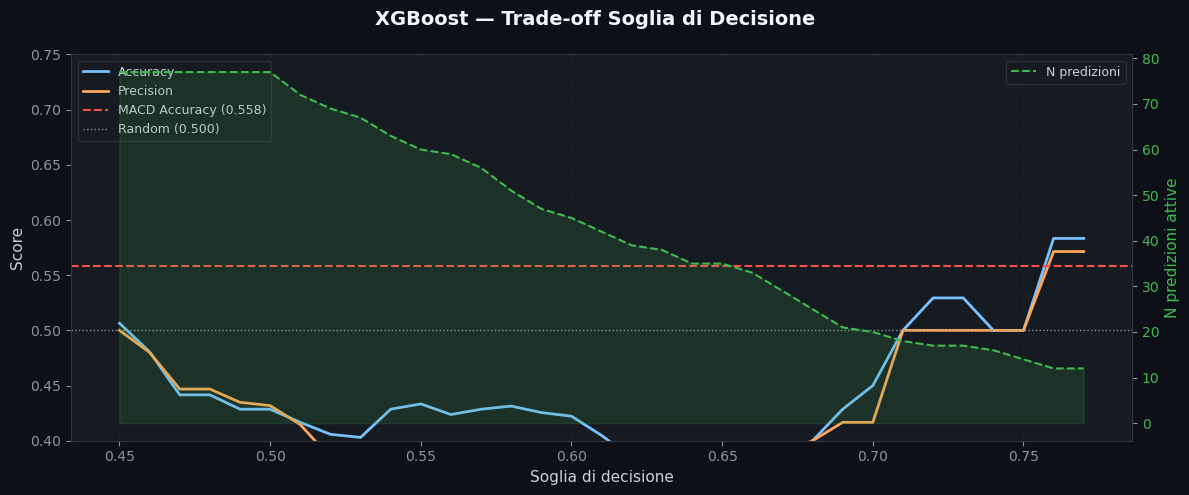

✅ Grafico soglia salvato.


In [35]:
import matplotlib.pyplot as plt
import numpy as np

thresholds = []
accs, precs, recs, counts = [], [], [], []

for threshold in np.arange(0.45, 0.80, 0.01):
    mask = (probabilities >= threshold) | (probabilities < (1 - threshold))
    preds_filtered   = (probabilities[mask] >= threshold).astype(int)
    actuals_filtered = actuals[mask]
    if len(actuals_filtered) < 10:
        break
    thresholds.append(threshold)
    accs.append(accuracy_score(actuals_filtered, preds_filtered))
    precs.append(precision_score(actuals_filtered, preds_filtered, zero_division=0))
    recs.append(recall_score(actuals_filtered, preds_filtered, zero_division=0))
    counts.append(len(actuals_filtered))

thresholds = np.array(thresholds)
accs       = np.array(accs)
precs      = np.array(precs)
counts     = np.array(counts)

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle('XGBoost — Trade-off Soglia di Decisione', fontsize=14, fontweight='bold', color='#f0f6fc')

ax1.plot(thresholds, accs,  color='#79c0ff', linewidth=2, label='Accuracy')
ax1.plot(thresholds, precs, color='#ffa657', linewidth=2, label='Precision')
ax1.axhline(0.558, color='#f85149', linewidth=1.5, linestyle='--', label='MACD Accuracy (0.558)')
ax1.axhline(0.500, color='#8b949e', linewidth=1.0, linestyle=':',  label='Random (0.500)')
ax1.set_ylabel('Score', fontsize=11)
ax1.set_xlabel('Soglia di decisione', fontsize=11)
ax1.set_ylim(0.40, 0.75)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.fill_between(thresholds, counts, alpha=0.15, color='#3fb950')
ax2.plot(thresholds, counts, color='#3fb950', linewidth=1.5, linestyle='--', label='N predizioni')
ax2.set_ylabel('N predizioni attive', fontsize=11, color='#3fb950')
ax2.tick_params(axis='y', labelcolor='#3fb950')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('./data/chart_threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafico soglia salvato.')

📊 Backtesting — Risultati

  Capitale iniziale:        $10,000
  Fee per transazione:       0.1%
  Numero di trade:           20

Metrica                      XGBoost         Buy & Hold
-------------------------------------------------------
Rendimento totale            -25.7%          -5.2%
Capitale finale              $     7,430    $     9,482
Sharpe Ratio (ann.)              -0.889        -0.100
Max Drawdown                 -51.3%          -46.8%


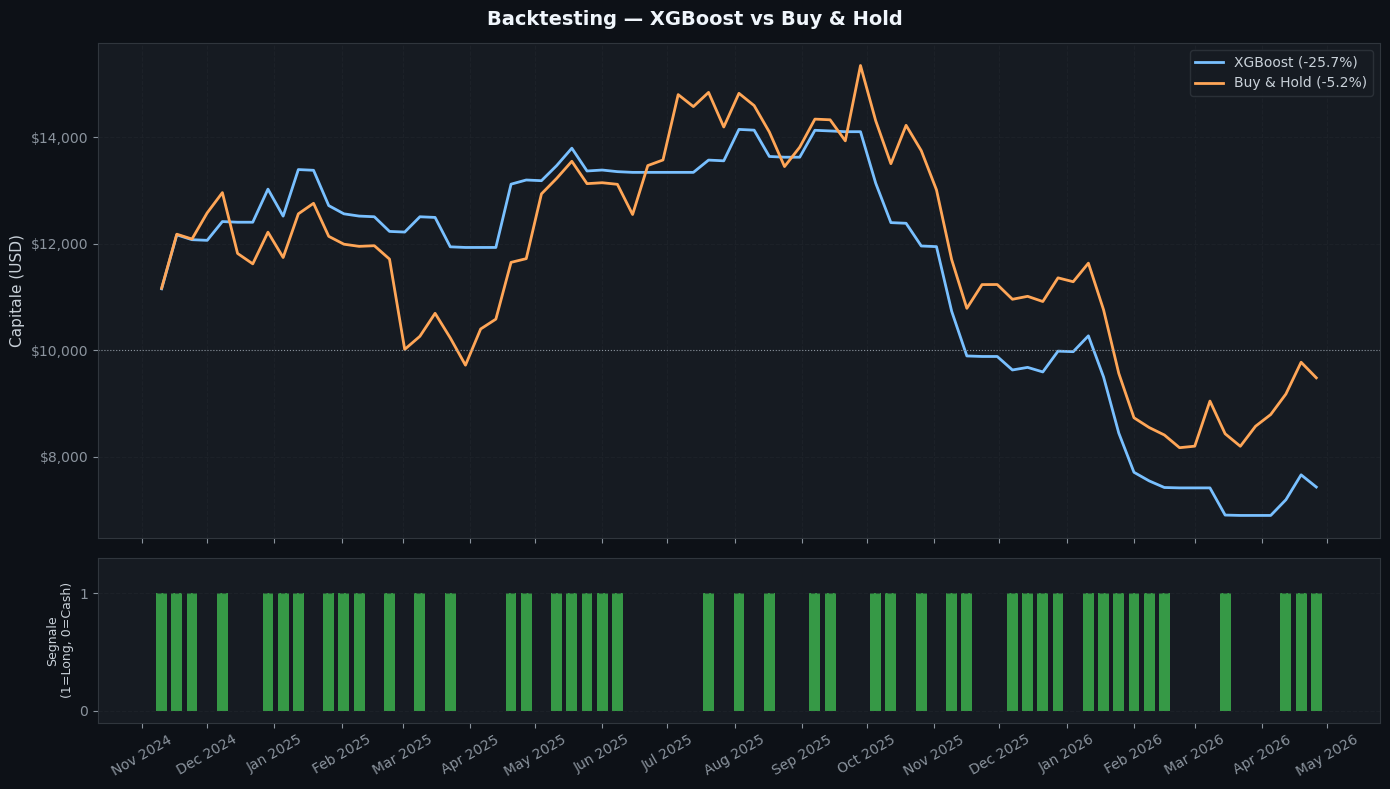

✅ Grafico backtesting salvato.


In [36]:
# ── BACKTESTING ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import accuracy_score

# Ricostruisci i prezzi di chiusura per il periodo di test
close = df_market['Close']

# Allinea prezzi al periodo walk-forward
bt = pd.DataFrame({
    'date':       test_dates,
    'prediction': predictions,
    'probability': probabilities,
    'actual':     actuals,
}, ).set_index('date')

# Aggiungi close[t] e close[t+1] per ogni settimana del test
bt['close_t']   = close.reindex(bt.index).values
bt['close_t1']  = [close.iloc[close.index.get_loc(t) + 1]
                   for t in bt.index]
bt['return_w']  = bt['close_t1'] / bt['close_t'] - 1

# ── Strategia modello: long se prediction=1, cash se prediction=0 ────────
CAPITAL_START   = 10_000.0
TRANSACTION_FEE = 0.001   # 0.1% per operazione (fee realistica)

capital_model = CAPITAL_START
capital_bh    = CAPITAL_START
equity_model  = []
equity_bh     = []
trades        = 0
in_position   = False

for _, row in bt.iterrows():
    ret = row['return_w']

    # Buy & Hold: sempre investito
    capital_bh *= (1 + ret)

    # Strategia modello
    if row['prediction'] == 1:
        if not in_position:
            capital_model *= (1 - TRANSACTION_FEE)  # fee entrata
            in_position = True
            trades += 1
        capital_model *= (1 + ret)
    else:
        if in_position:
            capital_model *= (1 - TRANSACTION_FEE)  # fee uscita
            in_position = False

    equity_model.append(capital_model)
    equity_bh.append(capital_bh)

bt['equity_model'] = equity_model
bt['equity_bh']    = equity_bh

# ── Metriche ─────────────────────────────────────────────────────────────
ret_model = bt['equity_model'].iloc[-1] / CAPITAL_START - 1
ret_bh    = bt['equity_bh'].iloc[-1]    / CAPITAL_START - 1

weekly_ret_model = bt['equity_model'].pct_change().dropna()
weekly_ret_bh    = bt['equity_bh'].pct_change().dropna()

sharpe_model = weekly_ret_model.mean() / weekly_ret_model.std() * np.sqrt(52)
sharpe_bh    = weekly_ret_bh.mean()    / weekly_ret_bh.std()    * np.sqrt(52)

# Max Drawdown
def max_drawdown(equity):
    roll_max = equity.cummax()
    drawdown = (equity - roll_max) / roll_max
    return drawdown.min()

mdd_model = max_drawdown(bt['equity_model'])
mdd_bh    = max_drawdown(bt['equity_bh'])

print('📊 Backtesting — Risultati\n')
print(f'  Capitale iniziale:        ${CAPITAL_START:,.0f}')
print(f'  Fee per transazione:       {TRANSACTION_FEE*100:.1f}%')
print(f'  Numero di trade:           {trades}')
print()
print(f'{"Metrica":<28} {"XGBoost":<15} {"Buy & Hold"}')
print('-' * 55)
print(f'{"Rendimento totale":<28} {ret_model*100:>+.1f}%          {ret_bh*100:>+.1f}%')
print(f'{"Capitale finale":<28} ${capital_model:>10,.0f}    ${capital_bh:>10,.0f}')
print(f'{"Sharpe Ratio (ann.)":<28} {sharpe_model:>10.3f}    {sharpe_bh:>10.3f}')
print(f'{"Max Drawdown":<28} {mdd_model*100:>+.1f}%          {mdd_bh*100:>+.1f}%')

# ── Grafico ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Backtesting — XGBoost vs Buy & Hold', fontsize=14,
             fontweight='bold', color='#f0f6fc')

# Equity curve
axes[0].plot(bt.index, bt['equity_model'], color='#79c0ff',
             linewidth=2, label=f'XGBoost ({ret_model*100:+.1f}%)')
axes[0].plot(bt.index, bt['equity_bh'],    color='#ffa657',
             linewidth=2, label=f'Buy & Hold ({ret_bh*100:+.1f}%)')
axes[0].axhline(CAPITAL_START, color='#8b949e', linewidth=0.8, linestyle=':')
axes[0].set_ylabel('Capitale (USD)', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(fontsize=10)
axes[0].grid(True)

# Segnali del modello
colors_signal = ['#3fb950' if p == 1 else '#f85149' for p in bt['prediction']]
axes[1].bar(bt.index, bt['prediction'], color=colors_signal,
            width=5, alpha=0.8)
axes[1].set_ylabel('Segnale\n(1=Long, 0=Cash)', fontsize=9)
axes[1].set_ylim(-0.1, 1.3)
axes[1].set_yticks([0, 1])
axes[1].grid(True, axis='y')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('./data/chart_backtesting.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafico backtesting salvato.')

In [37]:
print(f"Settimane con dati reali:  {df_sentiment['has_data'].sum()}")
print(f"Settimane interpolate:     {(df_sentiment['has_data'] == 0).sum()}")
print(f"Totale commenti:           {len(df_social)}")

Settimane con dati reali:  122
Settimane interpolate:     0
Totale commenti:           14182
